# Submitted by: Group TROVIA (Daza, Magallamento, Montuya)


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import qdesc as qd
import os

In [ ]:
os.chdir('/content/sample_data/')
df = pd.read_excel("NiTPHLeXVideoStreaming.xlsx")
df.head()

,user_location_type,peak_hour_flag,concurrent_users,buffer_events_per_session,mobile_error_rate(proportion),video_load_time(seconds),subtitle_accuracy_score(0-1),average_viewing_time(hours),churn_flag,server_cost(in USD),content_engagement_score(0-100)
0,urban,True,2173,3,0.04,6.09,0.93,0.29,Yes,402.79,75.55
1,rural,False,859,2,0.07,6.76,0.96,0.88,No,280.01,75.82
2,rural,False,207,2,0.09,5.15,0.95,1.55,No,235.06,76.42
3,urban,False,228,2,0.03,4.21,0.97,0.47,Yes,234.12,77.30
4,urban,True,1295,0,0.04,7.24,0.96,1.64,No,409.14,75.58


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3487 entries, 0 to 3486
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   user_location_type               3487 non-null   object 
 1   peak_hour_flag                   3487 non-null   bool   
 2   concurrent_users                 3487 non-null   int64  
 3   buffer_events_per_session        3487 non-null   int64  
 4   mobile_error_rate(proportion)    3487 non-null   float64
 5   video_load_time(seconds)         3487 non-null   float64
 6   subtitle_accuracy_score(0-1)     3487 non-null   float64
 7   average_viewing_time(hours)      3487 non-null   float64
 8   churn_flag                       3487 non-null   object 
 9   server_cost(in USD)              3487 non-null   float64
 10  content_engagement_score(0-100)  3487 non-null   float64
dtypes: bool(1), float64(6), int64(2), object(2)
memory usage: 276.0+ KB


In [ ]:
desc = df.describe()
desc.T

,count,mean,std,min,25%,50%,75%,max
concurrent_users,3487.0,897.733295,663.502054,200.00,450.500,702.00,965.000,2997.00
buffer_events_per_session,3487.0,1.299685,1.291198,0.00,0.000,1.00,2.000,9.00
mobile_error_rate(proportion),3487.0,0.061170,0.033716,0.01,0.030,0.06,0.080,0.15
video_load_time(seconds),3487.0,6.016496,1.927822,0.14,4.665,5.97,7.305,13.66
subtitle_accuracy_score(0-1),3487.0,0.930347,0.071291,0.49,0.930,0.95,0.960,1.03
average_viewing_time(hours),3487.0,1.052919,0.512704,0.10,0.680,1.05,1.410,2.98
server_cost(in USD),3487.0,320.718514,65.615514,122.83,274.475,314.39,363.080,573.89
content_engagement_score(0-100),3487.0,75.598641,1.713647,65.72,75.065,75.88,76.645,79.60


# Desriptive Analysis:

The descriptive statistics proides a summary for each variable. There are 3,487 observations for all variables.  

*   Concurrent users: The data shows high variability in user load and it is likely a right-skewed distributio. This can be interpreted that the system sees occasional burst of high traffic.
*   Buffer events per session: The mean indicates that there could be 1.3 buffers per session. The data is highly skewed to the right and this can be interpreted that most sessions have 0-2 buffers, or others may experience more, which could impact user satisfaction.
*   Mobile error rate: The average error rate is 6.1% and this is manageable but the 15% maximum could potentialy harm mobile experience.  
*   Video load times: The average load time is around 6 seconds which is typically considered slower.
*   Subtitle accuracy score: The average score is 0.93 which is high and the standard deviaton indicates that it is highly consistent.
*   Average viewing time: The average viewing time is approximately 1.05 hours which suggests a solid level of user engagement.
*   Server cost: The average cost is $321 per session and a wide range from $122.83 to $573.89 suggest that costs fluctuate based on usage, likely influenced by the variable number of concurrent users.
*   Content engagement score: Content on the platform is highly engaging, with a high average score of 75.6.


--- Variable: concurrent_users ---
  Anderson-Darling Statistic : 245.0672
  Critical Value (@ 5.0%) : 0.7860
  Decision : Reject Null


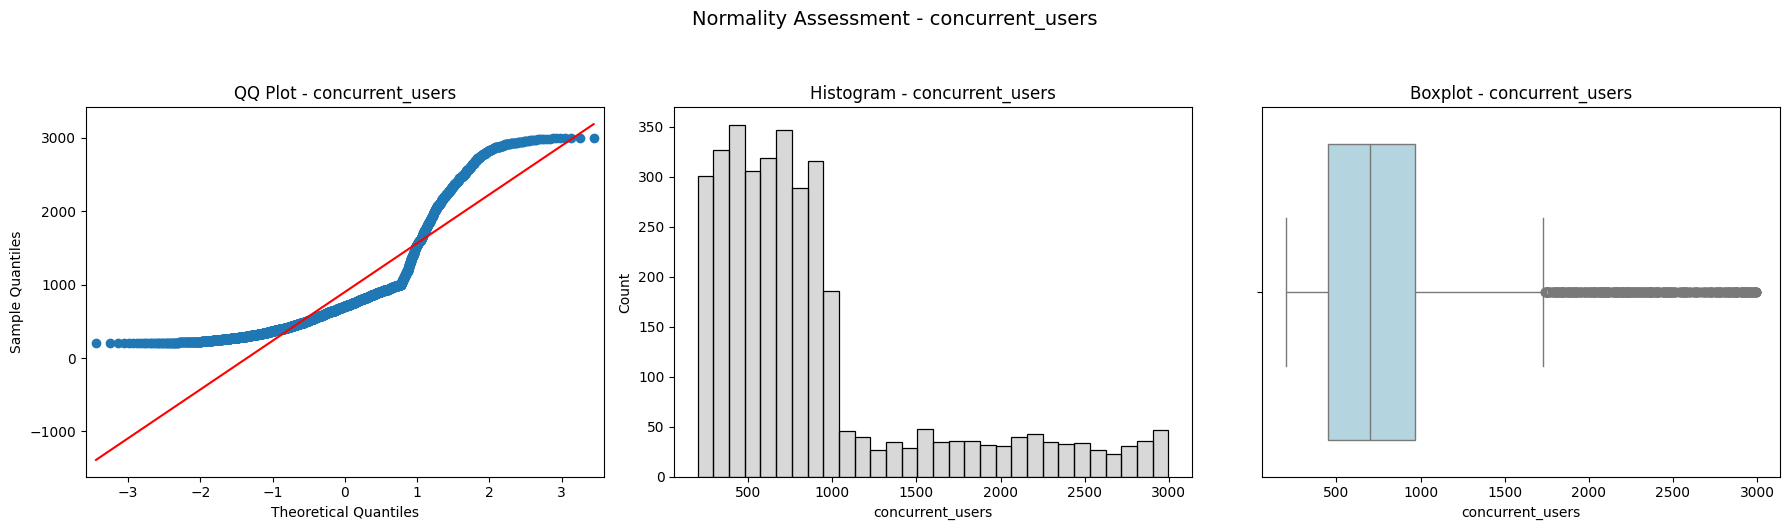


--- Variable: buffer_events_per_session ---
  Anderson-Darling Statistic : 170.2362
  Critical Value (@ 5.0%) : 0.7860
  Decision : Reject Null


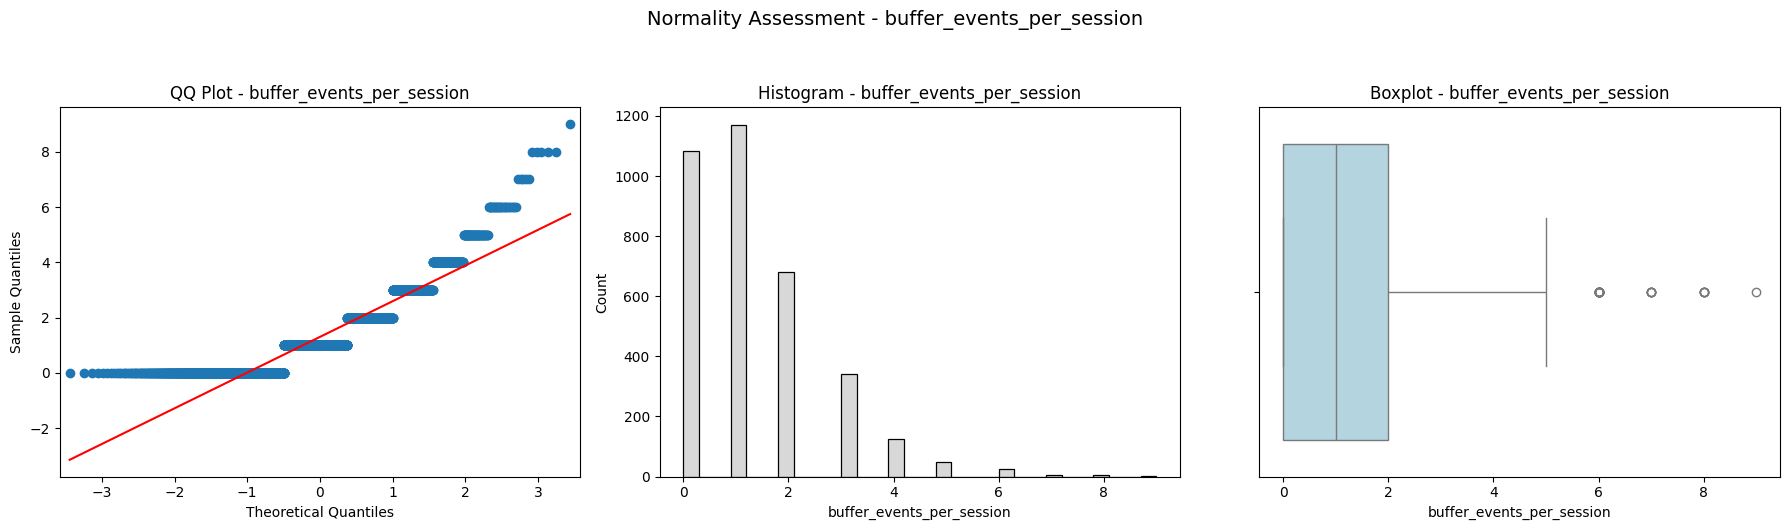


--- Variable: mobile_error_rate(proportion) ---
  Anderson-Darling Statistic : 55.7321
  Critical Value (@ 5.0%) : 0.7860
  Decision : Reject Null


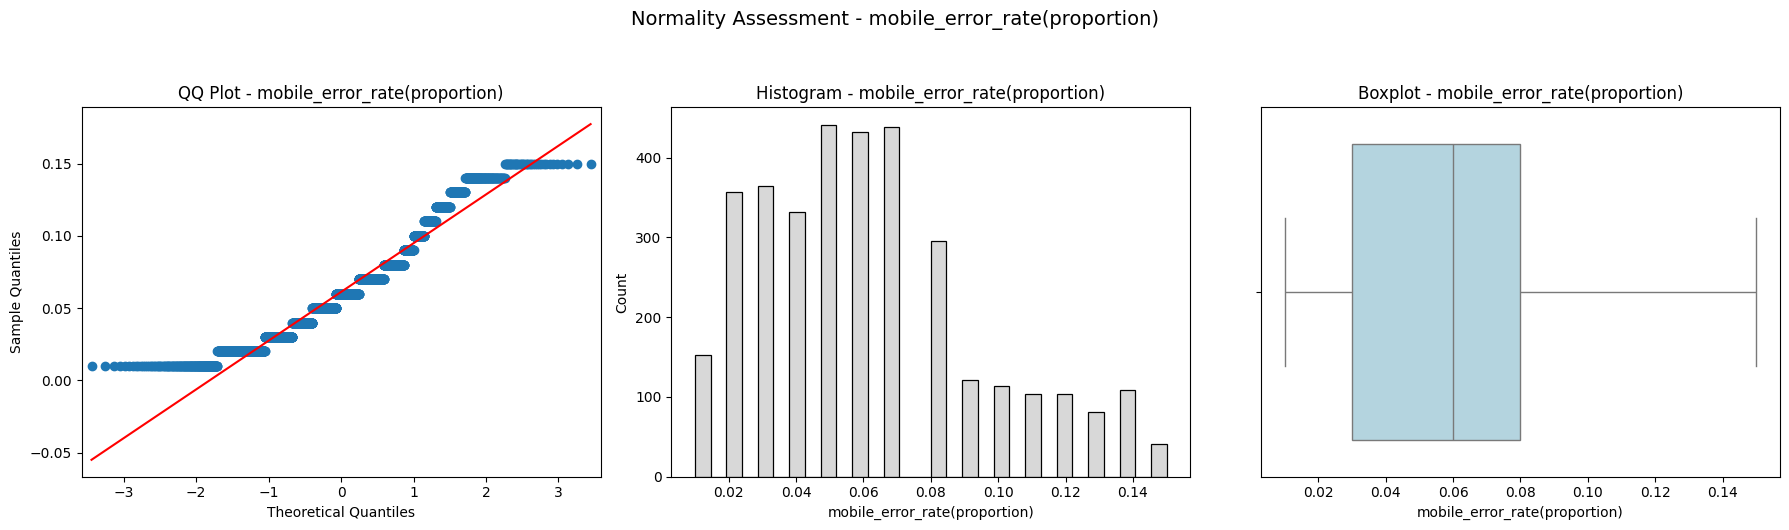


--- Variable: video_load_time(seconds) ---
  Anderson-Darling Statistic : 2.4418
  Critical Value (@ 5.0%) : 0.7860
  Decision : Reject Null


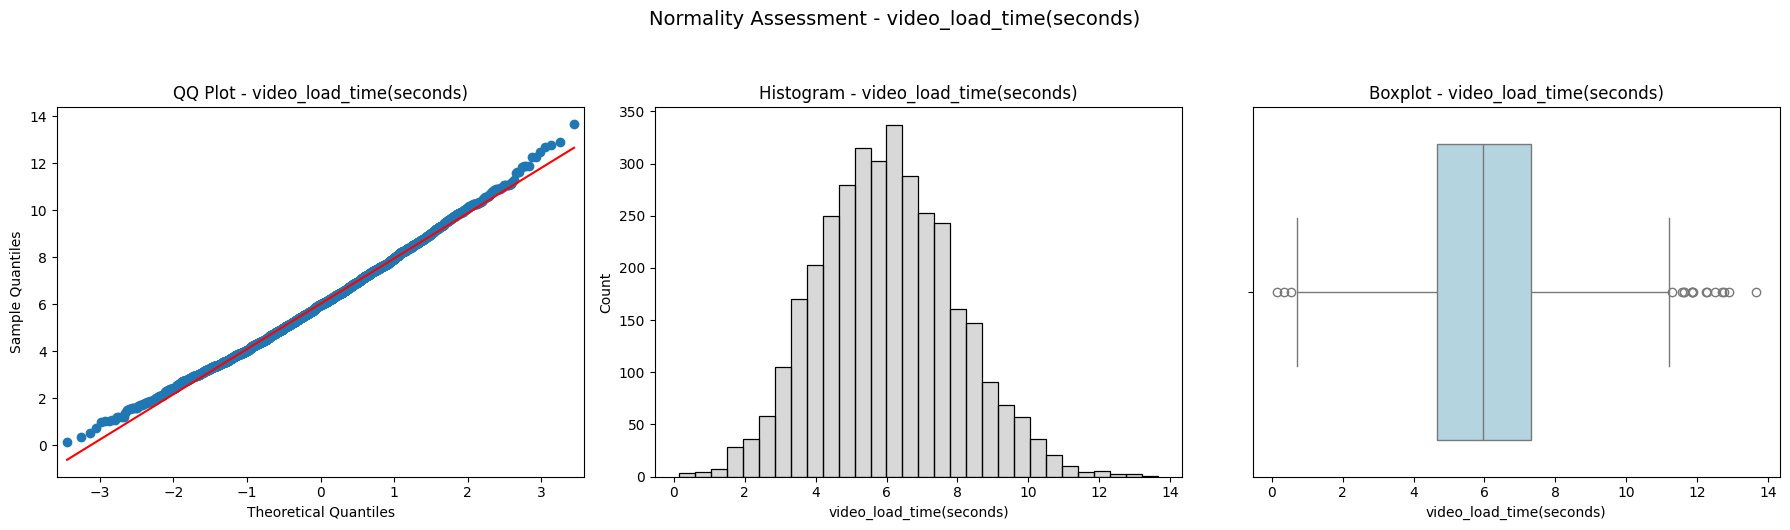


--- Variable: subtitle_accuracy_score(0-1) ---
  Anderson-Darling Statistic : 499.5729
  Critical Value (@ 5.0%) : 0.7860
  Decision : Reject Null


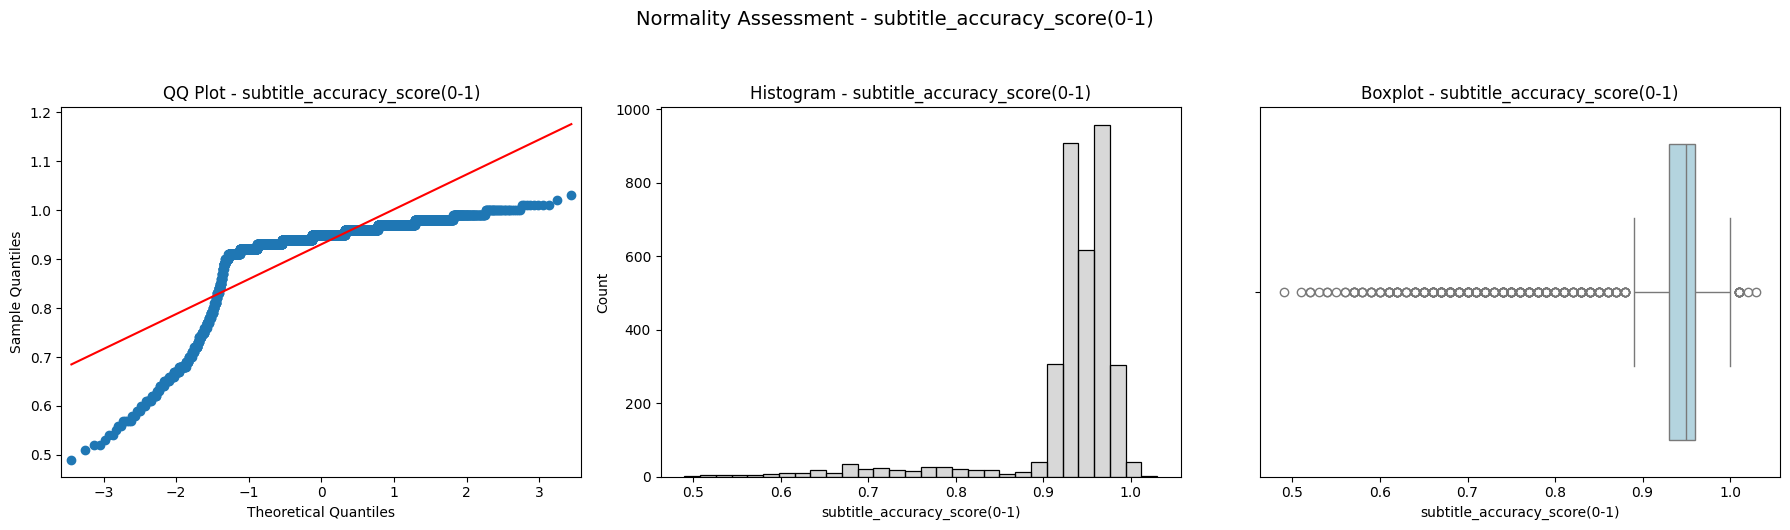


--- Variable: average_viewing_time(hours) ---
  Anderson-Darling Statistic : 3.6366
  Critical Value (@ 5.0%) : 0.7860
  Decision : Reject Null


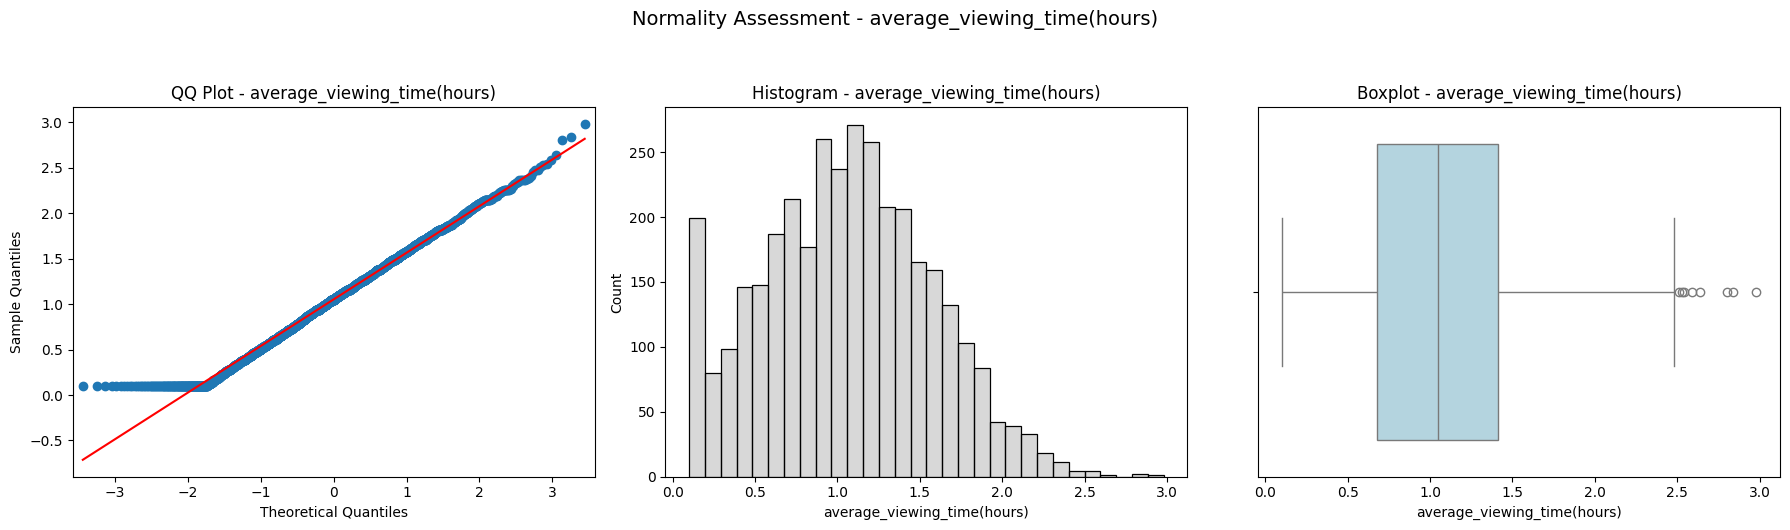


--- Variable: server_cost(in USD) ---
  Anderson-Darling Statistic : 9.1121
  Critical Value (@ 5.0%) : 0.7860
  Decision : Reject Null


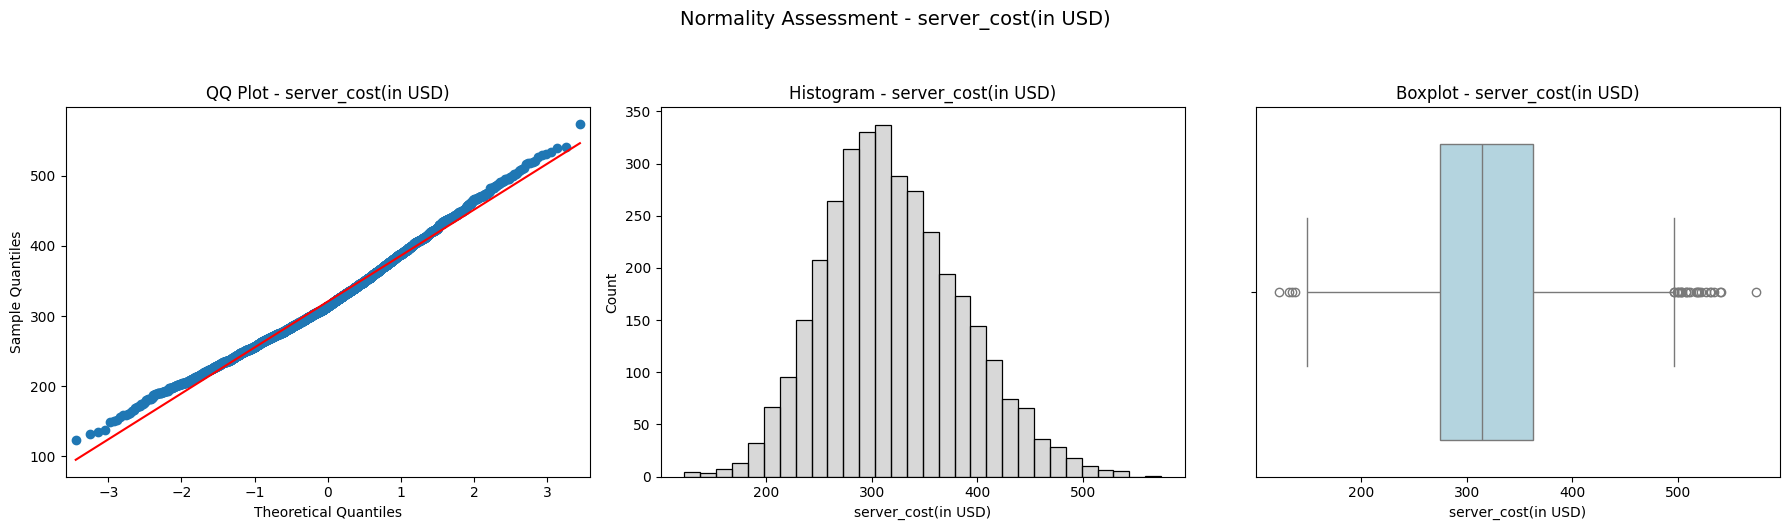


--- Variable: content_engagement_score(0-100) ---
  Anderson-Darling Statistic : 122.2160
  Critical Value (@ 5.0%) : 0.7860
  Decision : Reject Null


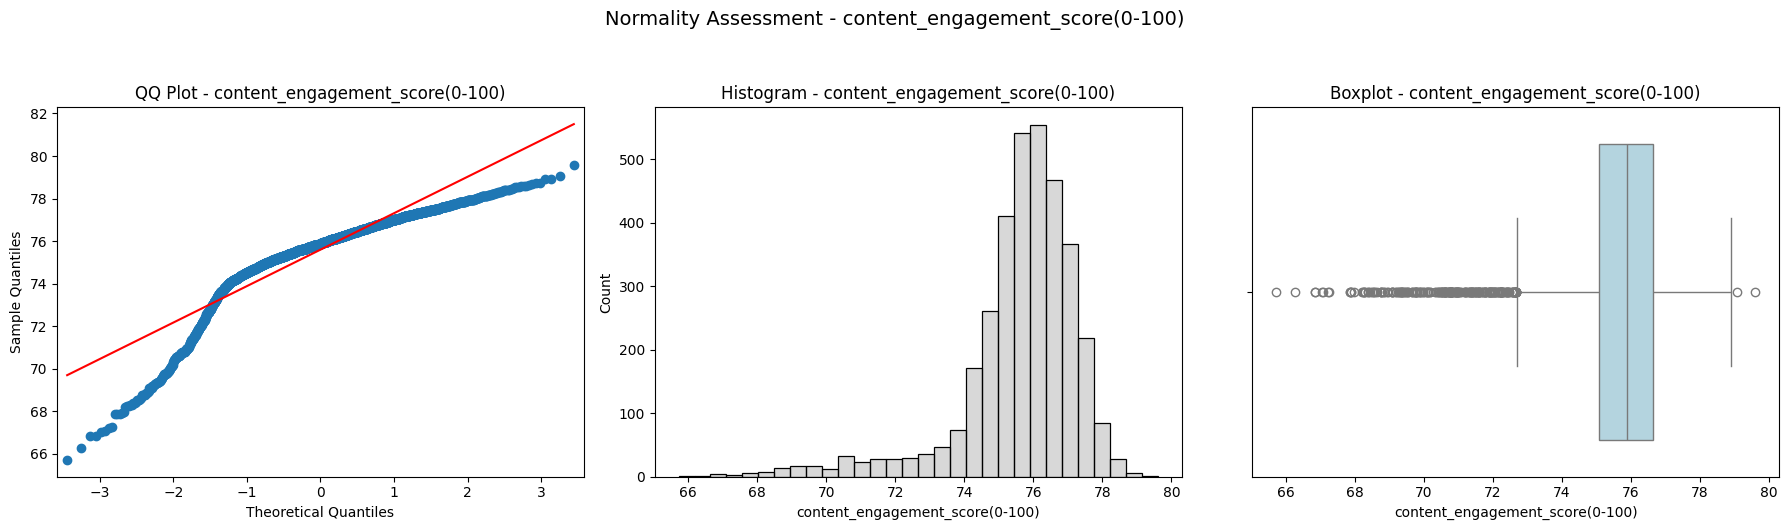

In [ ]:
qd.normcheck_dashboard(df)

# Normality Check:
*   Server Cost: The AD statistics is 9.1121 which is greater than the critical value indicates that we reject the null hypothesis. In the QQ plot, the data points largely follow the red diagonal line, but there's a slight S-curve and some deviations at the tails. The histogram has a bell-like shape but it is not perfectly symmetrical. Thus, while the histogram has a generally bell-like shape, the Anderson-Darling test decisively shows that is not normally distributed.
*   Video Load Times: We reject null hypothesis since AD statistics is higher than the critical value. The histogram shows a good approximation of a bell curve, with a peak near the center but it is not normaly distributed. The boxplot is highly symmetrical, with the median line close to the center of the box. The whiskers are also of similar length, and outliers are present on both sides.
*   Average Viewing Time: The AD statistics is higher which mean we reject the null hypothesis and it is not normally distributed. The histogram has a somewhat bell-like shape, but it is slightly skewed to the right. The boxplot appears fairly symmetrical, with the median close to the center.  
*   Concurrent Users: The AD statistics is higher which means we reject the null hypothesis and it is not normally distributed. The histogram is clearly right-skewed, with a long tail extending to the right. The boxplot shows the median line shifted to the left within the box and a very long whisker and many outliers on the right side.
*   Subtitle Accuracy: The AD statistics is higher which means that we reject the null hypothesis and the data is not normally distributed. The histogram is a clear example of a non-normal distribution, with a sharp, tall peak on the right side.  The boxplot shows a very short box and a long whisker to the left, indicating a left-skewed distribution and there are also many outliers.
*   Buffer Events per Session: The AD statistics is higher which means that we reject the null hypothesis and the data is not normally distributed. he histogram is extremely right-skewed and the boxplot is high symmetrical.
*   Mobile Error Rate: The AD statistics is higher which means that we reject the null hypothesis and the data is not normally distributed. The histogram is multi-modal, with several peaks and the boxplot is fairly symmetrical.
*   Content Engagement: The AD statistics is higher which means that we reject the null hypothesis and the data is not normally distributed. The histogram has a sharp peak with a narrow spread and the boxplot indicates that large portion of the data is concentrated within a small range where the  left whisker is longer and has more outliers, suggesting a left-skew.




# Method Used: Spearman Correlation
CORRELATION ANALYSIS

Spearman Correlation Matrix:
                                 concurrent_users  buffer_events_per_session  \
concurrent_users                         1.000000                   0.273384   
buffer_events_per_session                0.273384                   1.000000   
mobile_error_rate(proportion)            0.007325                   0.025067   
video_load_time(seconds)                 0.296516                   0.177396   
subtitle_accuracy_score(0-1)             0.013369                   0.003336   
average_viewing_time(hours)             -0.118941                  -0.232247   
server_cost(in USD)                      0.429093                   0.241315   
content_engagement_score(0-100)         -0.224922                  -0.141050   

                                 mobile_error_rate(proportion)  \
concurrent_users                                      0.007325   
buffer_events_per_session                             0.025067   
mobile_error_rate(proportion)                       

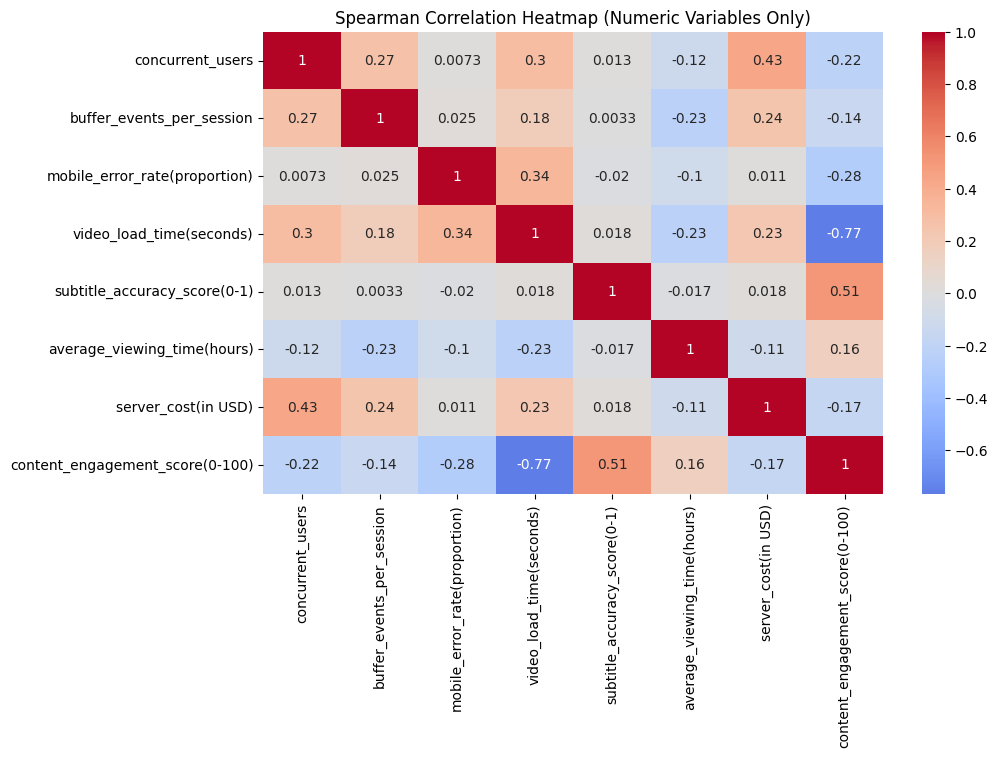

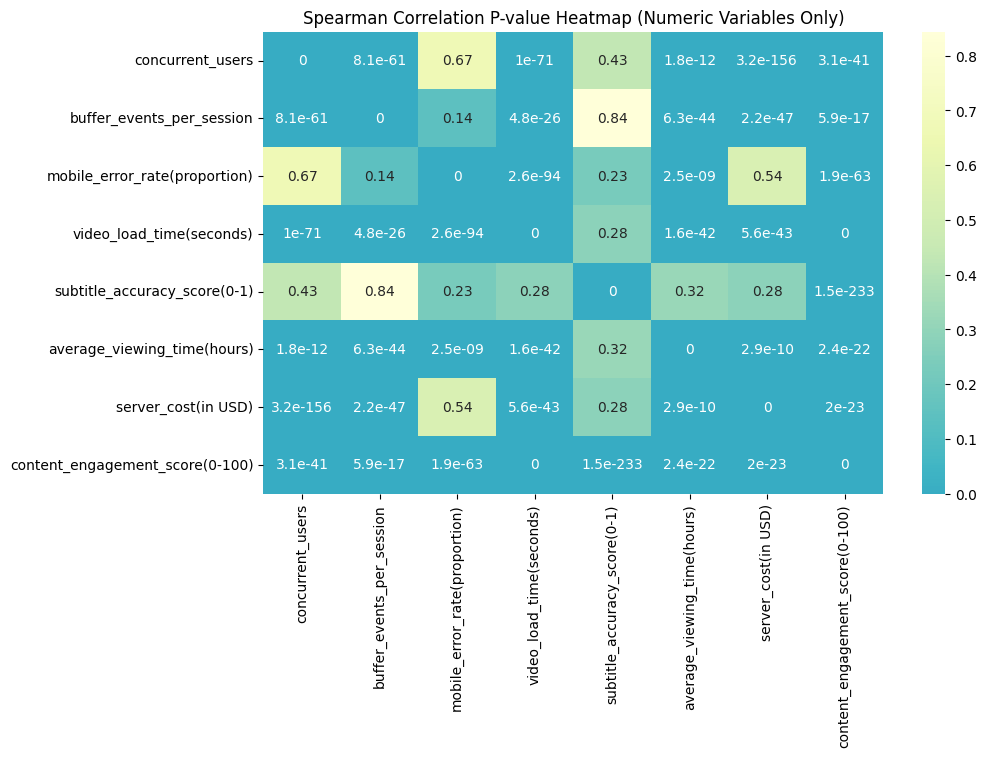

In [ ]:
# 1. Keep only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# 2. Compute Spearman correlation matrix with p-values
cols = numeric_df.columns
corr_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), columns=cols, index=cols)
pval_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), columns=cols, index=cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        rho, pval = spearmanr(numeric_df[cols[i]], numeric_df[cols[j]], nan_policy='omit')
        corr_matrix.iloc[i, j] = rho
        pval_matrix.iloc[i, j] = pval

# 3. Show correlation matrix
print("Spearman Correlation Matrix:")
print(corr_matrix)

print("\nP-value Matrix:")
print(pval_matrix)

# 4. Visualize correlations
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Spearman Correlation Heatmap (Numeric Variables Only)")
plt.show()

# 5. Visualize significance (p-values)
plt.figure(figsize=(10,6))
sns.heatmap(pval_matrix, annot=True, cmap='YlGnBu_r', center=0.05)
plt.title("Spearman Correlation P-value Heatmap (Numeric Variables Only)")
plt.show()

NOTE: Given their strong relationship, these pairs are the most critical for NiPHLeX to focus on:

In [ ]:
engagement = "content_engagement_score(0-100)"
load_time = "video_load_time(seconds)"
buffer_events = "buffer_events_per_session"
mobile_error = "mobile_error_rate(proportion)"
subtitle_acc = "subtitle_accuracy_score(0-1)"
viewing_time = "average_viewing_time(hours)"
server_cost = "server_cost(in USD)"
concurrent_users = "concurrent_users"

Correlation with Engagement:
video_load_time(seconds)          -0.766026
buffer_events_per_session         -0.141050
mobile_error_rate(proportion)     -0.279150
content_engagement_score(0-100)    1.000000
Name: content_engagement_score(0-100), dtype: float64


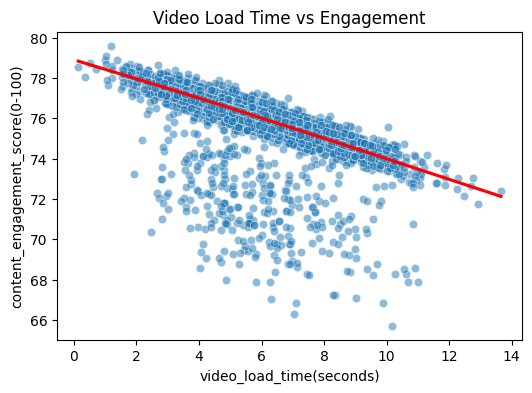

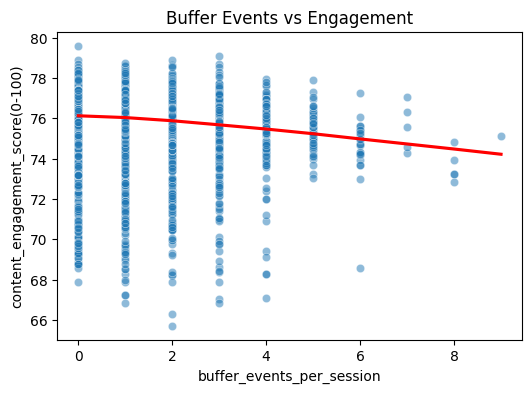

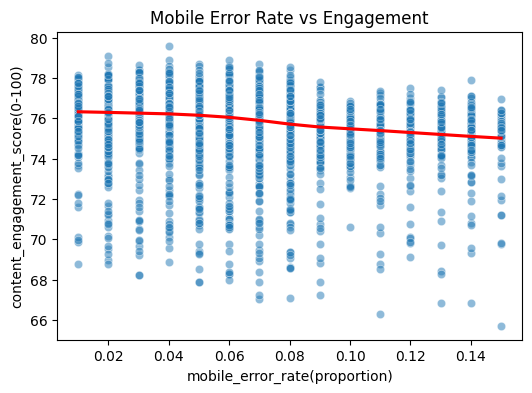

In [ ]:
print("Correlation with Engagement:")
print(df[[load_time, buffer_events, mobile_error, engagement]].corr(method='spearman')[engagement])

# 2. Visuals
plt.figure(figsize=(6,4))
sns.scatterplot(x=load_time, y=engagement, data=df, alpha=0.5)
sns.regplot(x=load_time, y=engagement, data=df, scatter=False, color='red', lowess=True)
plt.title("Video Load Time vs Engagement")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=buffer_events, y=engagement, data=df, alpha=0.5)
sns.regplot(x=buffer_events, y=engagement, data=df, scatter=False, color='red', lowess=True)
plt.title("Buffer Events vs Engagement")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=mobile_error, y=engagement, data=df, alpha=0.5)
sns.regplot(x=mobile_error, y=engagement, data=df, scatter=False, color='red', lowess=True)
plt.title("Mobile Error Rate vs Engagement")
plt.show()

Analysis:


*  Video Load Time VS Engagement - Downward Slope, meaning as load time increases, the engagement drops heavily. (The longer a video loads, the less engaged users are.)
*   Buffer Events VS Engagement - Downward Slope, meaning as buffer events increase, engagement drops slightly. (The more a video buffers, the less engaged users are.)
*   Mobile Error Rate VS Engagement - Downward Slope, meaning as buffer events increase, engagement drops slightly. (Users experiencing more errors on mobile engage less with the platform.)









Correlation between Subtitle Accuracy and Engagement:
subtitle_accuracy_score(0-1)       0.51313
content_engagement_score(0-100)    1.00000
Name: content_engagement_score(0-100), dtype: float64


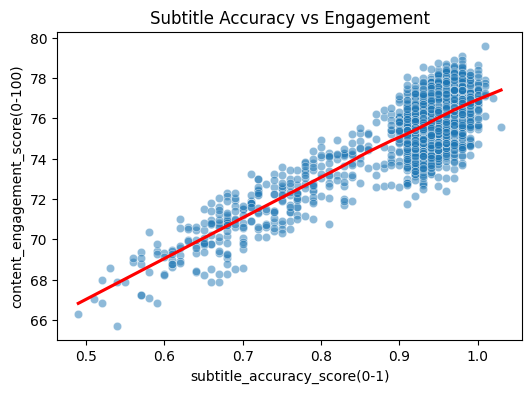

In [ ]:
# Correlation value
print("Correlation between Subtitle Accuracy and Engagement:")
print(df[[subtitle_acc, engagement]].corr(method='spearman')[engagement])

# Visual
plt.figure(figsize=(6,4))
sns.scatterplot(x=subtitle_acc, y=engagement, data=df, alpha=0.5)
sns.regplot(x=subtitle_acc, y=engagement, data=df, scatter=False, color='red', lowess=True)
plt.title("Subtitle Accuracy vs Engagement")
plt.show()

Analysis:

Subtitle VS Engagement - Upward Slope, meaning the higher the subtitle accuracy, the higher the engagement. (ρ = 0.51, moderate positive correlation).

Correlations with Server Cost:
concurrent_users             0.429093
buffer_events_per_session    0.241315
video_load_time(seconds)     0.229704
server_cost(in USD)          1.000000
Name: server_cost(in USD), dtype: float64


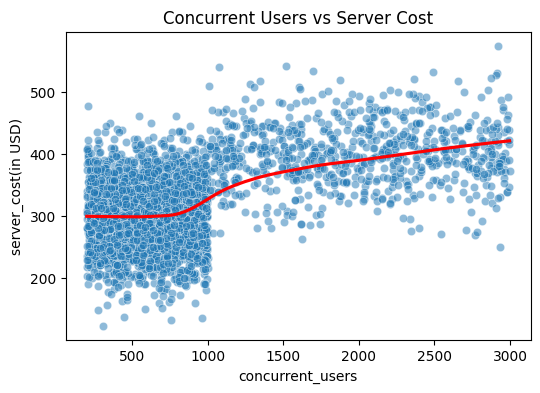

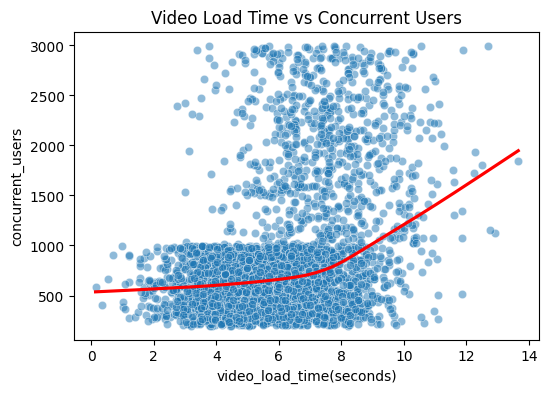

In [ ]:
# Correlations
print("Correlations with Server Cost:")
print(df[[concurrent_users, buffer_events, load_time, server_cost]].corr(method='spearman')[server_cost])

# Visuals
plt.figure(figsize=(6,4))
sns.scatterplot(x=concurrent_users, y=server_cost, data=df, alpha=0.5)
sns.regplot(x=concurrent_users, y=server_cost, data=df, scatter=False, color='red', lowess=True)
plt.title("Concurrent Users vs Server Cost")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=load_time, y=concurrent_users, data=df, alpha=0.5)
sns.regplot(x=load_time, y=concurrent_users, data=df, scatter=False, color='red', lowess=True)
plt.title("Video Load Time vs Concurrent Users")
plt.show()


Analysis:

Concurrent Users vs Server Cost – Upward Slope, meaning the more users online, the higher the server cost.

Video Load Time vs Concurrent Users – Upward Slope, meaning more users lead to longer video load times.

Correlation between Viewing Time and Engagement:
average_viewing_time(hours)        0.163598
content_engagement_score(0-100)    1.000000
Name: content_engagement_score(0-100), dtype: float64


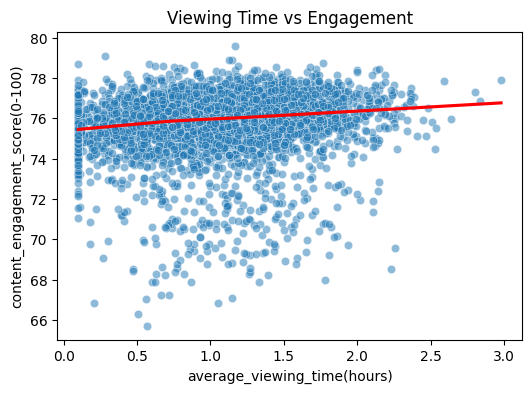

In [ ]:
# Correlation
print("Correlation between Viewing Time and Engagement:")
print(df[[viewing_time, engagement]].corr(method='spearman')[engagement])

# Visual
plt.figure(figsize=(6,4))
sns.scatterplot(x=viewing_time, y=engagement, data=df, alpha=0.5)
sns.regplot(x=viewing_time, y=engagement, data=df, scatter=False, color='red', lowess=True)
plt.title("Viewing Time vs Engagement")
plt.show()


Analysis:

Viewing Time vs Engagement – Slightly Upward Slope, meaning some users with short sessions still report high engagement, while some with long sessions show only moderate engagement.